### 1) Understanding Data

* a) Understand Columns
* b) check dtype -> df[col].astype()
* c) Describe Numerical Cols
* d) Describe Categorical Cols

### 2) EXTRACT FEATURES + EDA (uni - bi(heatmap) - multi) -> Insights:
* Uni-variate Analysis
    - Histogram (values)
    - distplot (distrbution)
    - catigorical (pie / count)

* Bi-Variate Analysis
    * Num vs Num
        - Scatter (relationship btn 2 variables)
        - line (trend with time)
    * Num vs Cat (distrbution)
        - box 
        - violin
        - strip
    * Cat vs Cat
        - bar (estimate plot)
        - countplot (count rows)

* Multi-Variate Analysis
    * Pairplot

### 3) Pre-Processing Mind Map:
* a) Detect & Handle Duplicates
* b) train_test_split
* c) Detect & Handle NaNs
* d) Detect & Handle Outliers
* e) Encoding: (Ordinal:[OrdinalEncoder, LabelEncoder] - Nominal: [< 7 uniques(OneHotEncoding), > 7 uniques (BinaryEncoder)])
* f) Imbalanced: X_train_resampled
* g) Scaling: StandardScaler, MinMaxScaler, RobustScaler: X_train_resampled_scaled

In [1]:
# Details of Extract + Scenarios of Handling NaNs + Duplicates + Outliers

## EXTRACT FEATURES:
* 1) Domain Knowledge
---

* 2) DateTime => .dt + (seasons / day_parts)
---

* 3) Strings (Break - Join) => .str
---

* 4) Browser Info => pc/mobile + {os + browser + device}
---

* 5) IP => {country, city, region, latitude, longitude}
---

* 6) Geospatial data => (latitude,longitude) <=> location
---

* 7) Text => sklearn.feature_extraction.text (CountVectorizer, TfIdfVectorizer)
---
# 1) Detect & Handle NaNs
## Detect NaNs:
* Numeric column: pd.to_numeric(erros='coerce')
* Categorical column: df[col].unique() -> df[col].replace(?, np.nan)

## Handle NaNs:
    
* COL>50% NaNs: drop column
* 1->5% NaNs: dropna (rows)
* in between: impute NaNs (df[col].mean() x) -> (class SimpleImputer/KNNImputer)
---
## 2) Duplicates

* Detect Duplicates: df.duplicated().sum()
* Handle Duplicates: df.drop_duplicates(inplace=True)
---
## 3) Outliers

### Detect:
* box plot

### Handle:
* Normal Distrbution:
    - df[col][df[col] > ub] = ub or (mean/median/mode)
    - df[col][df[col] < lb] = lb or (mean/median/mode)
* Right Skewed (use mathmatical transformer):
    - log/sqrt
* Left Skewed (use mathmatical transformer):
    - 1/x
---

### 1) Understanding Data

* a) Understand Columns
* b) check datatypes
* c) Describe Numerical Cols
* d) Describe Categorical Cols

In [2]:
# manpulation
import numpy as np
import pandas as pd

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Feature Extraction
import user_agents # get info from user_agent (browser_info)
from ip2geotools.databases.noncommercial import DbIpCity as ip2geo # get location from ip
from geopy.distance import great_circle # distance btn 2 (lat,long)
from geopy.geocoders import Nominatim # geocode("place") / reverse("lat,long")
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer # text feature

# Pre-Processing
from sklearn.model_selection import train_test_split # train-test-split
from sklearn.impute import SimpleImputer, KNNImputer # detect & handle NaNs
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder # Ordinal Encoding, Nominal Encoding
from category_encoders import BinaryEncoder # Nominal Encoding 
from imblearn.under_sampling import RandomUnderSampler # undersampling
from imblearn.over_sampling import RandomOverSampler, SMOTE # oversampling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler # Scaling

In [3]:
df = pd.read_csv("DataAnalyst.csv")
df

,Unnamed: 0,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
2249,2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2250,2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
2251,2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


In [4]:
# * a) Understand Columns
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1


In [5]:
# * b) check datatypes
# b) check dtype -> df[col].astype()
df.info()
# min_salary_estimate, max_salary_estimate
# min_size, max_size
# min_revenue, max_revenue
# competitors => -1 (None)
# Easy Apply -1 => (False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2253 entries, 0 to 2252
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Job Title          2253 non-null   object 
 1   Salary Estimate    2253 non-null   object 
 2   Job Description    2253 non-null   object 
 3   Rating             2253 non-null   float64
 4   Company Name       2252 non-null   object 
 5   Location           2253 non-null   object 
 6   Headquarters       2253 non-null   object 
 7   Size               2253 non-null   object 
 8   Founded            2253 non-null   int64  
 9   Type of ownership  2253 non-null   object 
 10  Industry           2253 non-null   object 
 11  Sector             2253 non-null   object 
 12  Revenue            2253 non-null   object 
 13  Competitors        2253 non-null   object 
 14  Easy Apply         2253 non-null   object 
dtypes: float64(1), int64(1), object(13)
memory usage: 264.1+ KB


In [6]:
# min_salary_estimate, max_salary_estimate
def extract_min_max_salary(arg):
    if arg == '-1':
        return pd.Series([np.nan, np.nan])
    
    min_max_salary = arg.split(" (")[0]
    min_max_salary = min_max_salary.split("-")
    
    # min_salary
    min_max_salary[0] = min_max_salary[0].strip("$")
    if 'k' in min_max_salary[0].lower():
        min_salary = int(min_max_salary[0].strip("K")) * 1000
    else:
        min_salary = int(min_max_salary[0])
    
    # max_salary
    min_max_salary[1] = min_max_salary[1].strip("$")
    if 'k' in min_max_salary[1].lower():
        max_salary = int(min_max_salary[1].strip("K")) * 1000
    else:
        max_salary = int(min_max_salary[1])
    
    return pd.Series([min_salary, max_salary])


df[['min_salary_estimate', 'max_salary_estimate']] = df['Salary Estimate'].apply(extract_min_max_salary)
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True,37000.0,66000.0
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,37000.0,66000.0
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37000.0,66000.0
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,37000.0,66000.0
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37000.0,66000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1,78000.0,104000.0
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78000.0,104000.0
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1,78000.0,104000.0
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1,78000.0,104000.0


In [7]:
df['Size'].unique()

array(['201 to 500 employees', '10000+ employees',
       '1001 to 5000 employees', '501 to 1000 employees',
       '5001 to 10000 employees', '1 to 50 employees',
       '51 to 200 employees', 'Unknown', '-1'], dtype=object)

In [8]:
# min_size, max_size
def extract_min_max_size(arg):
    if arg in ['-1', 'Unknown']:
        return pd.Series([np.nan, np.nan])
    
    min_max_size = arg = arg.strip(" employees")
    if '+' in min_max_size:
        min_size = 0
        max_size = int(min_max_size.strip("+"))
    else:
        min_max_size = min_max_size.split(" to ")
        min_size = int(min_max_size[0])
        max_size = int(min_max_size[1])
    
    return pd.Series([min_size, max_size])


df[['min_size', 'max_size']] = df['Size'].apply(extract_min_max_size)
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,Industry,Sector,Revenue,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,Social Assistance,Non-Profit,$100 to $500 million (USD),-1,True,37000.0,66000.0,201.0,500.0
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,Health Care Services & Hospitals,Health Care,$2 to $5 billion (USD),-1,-1,37000.0,66000.0,0.0,10000.0
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,Internet,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37000.0,66000.0,1001.0,5000.0
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,IT Services,Information Technology,$50 to $100 million (USD),-1,-1,37000.0,66000.0,201.0,500.0
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37000.0,66000.0,501.0,1000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,Staffing & Outsourcing,Business Services,Unknown / Non-Applicable,-1,-1,78000.0,104000.0,51.0,200.0
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,Wholesale,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78000.0,104000.0,0.0,10000.0
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,-1,-1,-1,-1,-1,78000.0,104000.0,NaN,NaN
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,Enterprise Software & Network Solutions,Information Technology,$25 to $50 million (USD),-1,-1,78000.0,104000.0,201.0,500.0


In [9]:
# min_revenue, max_revenue
df['Revenue']

0       $100 to $500 million (USD)
1           $2 to $5 billion (USD)
2         Unknown / Non-Applicable
3        $50 to $100 million (USD)
4       $100 to $500 million (USD)
                   ...            
2248      Unknown / Non-Applicable
2249            $10+ billion (USD)
2250                            -1
2251      $25 to $50 million (USD)
2252        $2 to $5 billion (USD)
Name: Revenue, Length: 2253, dtype: object

In [10]:
df['Revenue'].unique()

array(['$100 to $500 million (USD)', '$2 to $5 billion (USD)',
       'Unknown / Non-Applicable', '$50 to $100 million (USD)',
       '$1 to $2 billion (USD)', '$5 to $10 billion (USD)',
       '$1 to $5 million (USD)', '$25 to $50 million (USD)',
       '$10+ billion (USD)', 'Less than $1 million (USD)',
       '$10 to $25 million (USD)', '-1',
       '$500 million to $1 billion (USD)', '$5 to $10 million (USD)'],
      dtype=object)

In [11]:
def format_revenue(arg):
    # $100 to $500 million (USD) - case_1
    # '$2 to $5 billion (USD)' - case_2
    # 'Unknown / Non-Applicable' & -1 - case_3
    # '$10+ billion (USD)' - case_4
    # 'Less than $1 million (USD)' - case_5
    # '$500 million to $1 billion (USD)'
    if 'unknown' in arg.lower() or arg == '-1':
        return pd.Series([np.nan, np.nan])
    
    if '+' in arg:
        words = arg.split("+ ")
        min_revenue = 0
        max_revenue = int(words[0].strip("$"))
        unit = words[1].strip(" (USD)")
        max_revenue *= 1e9
        min_revenue *= 1e9
    
    elif "less than" in arg.lower():
        min_revenue = 0
        max_revenue, unit = arg.split("than")[1].strip(" $").strip(" (USD)").split(" ")
        if 'million' in unit:
            min_revenue *= 1e6
            max_revenue = int(max_revenue) * 1e6
    else:
        words = arg.split(" to ")
        if (('million' in words[0]) or ('billion' in words[0])) and (('million' in words[1]) or ('billion' in words[1])):
            min_revenue, unit_1 = words[0].split(" ")
            max_revenue, unit_2 = words[1].strip(" (USD)").split(" ")

            min_revenue = int(min_revenue.strip("$"))
            max_revenue = int(max_revenue.strip("$"))
            if unit_1.lower() == 'million':
                min_revenue *= 1e6
            
            elif unit_1.lower() == 'billion':
                min_revenue *= 1e9

            if unit_2.lower() == 'million':
                max_revenue *= 1e6
            
            elif unit_2.lower() == 'billion':
                max_revenue *= 1e9 

        else:
            min_revenue = int(words[0].strip().strip("$")) # "100"
            (max_revenue, unit) = words[1].strip(" ").strip("$").strip(" (USD)").split(" ") # $500 million (USD)
            max_revenue = int(max_revenue)
            if unit.lower() == 'million':
                min_revenue *= 1e6
                max_revenue *= 1e6
            
            elif unit.lower() == 'billion':
                min_revenue *= 1e9
                max_revenue *= 1e9
    return pd.Series([min_revenue, max_revenue])
    
df[['min_revenue', 'max_revenue']] = df['Revenue'].apply(format_revenue)
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Sector,Revenue,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n3.2,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,...,Non-Profit,$100 to $500 million (USD),-1,True,37000.0,66000.0,201.0,500.0,1.000000e+08,5.000000e+08
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n3.8,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,...,Health Care,$2 to $5 billion (USD),-1,-1,37000.0,66000.0,0.0,10000.0,2.000000e+09,5.000000e+09
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n3.4,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,...,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37000.0,66000.0,1001.0,5000.0,NaN,NaN
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n4.1,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,...,Information Technology,$50 to $100 million (USD),-1,-1,37000.0,66000.0,201.0,500.0,5.000000e+07,1.000000e+08
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n3.9,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,...,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37000.0,66000.0,501.0,1000.0,1.000000e+08,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n2.5","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,...,Business Services,Unknown / Non-Applicable,-1,-1,78000.0,104000.0,51.0,200.0,NaN,NaN
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n2.9,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,...,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78000.0,104000.0,0.0,10000.0,0.000000e+00,1.000000e+10
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,...,-1,-1,-1,-1,78000.0,104000.0,NaN,NaN,NaN,NaN
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n3.1,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,...,Information Technology,$25 to $50 million (USD),-1,-1,78000.0,104000.0,201.0,500.0,2.500000e+07,5.000000e+07


In [12]:
def format_company_name(row):
    if pd.isna(row['Company Name']):
        return row['Company Name']
    
    return row['Company Name'].strip(f" {row['Rating']}")


df['Company Name'] = df.apply(format_company_name, axis=1)
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Sector,Revenue,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n,"New York, NY","New York, NY",201 to 500 employees,1961,Nonprofit Organization,...,Non-Profit,$100 to $500 million (USD),-1,True,37000.0,66000.0,201.0,500.0,1.000000e+08,5.000000e+08
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n,"New York, NY","New York, NY",10000+ employees,1893,Nonprofit Organization,...,Health Care,$2 to $5 billion (USD),-1,-1,37000.0,66000.0,0.0,10000.0,2.000000e+09,5.000000e+09
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n,"New York, NY","New York, NY",1001 to 5000 employees,2003,Company - Private,...,Information Technology,Unknown / Non-Applicable,GoDaddy,-1,37000.0,66000.0,1001.0,5000.0,NaN,NaN
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n,"New York, NY","McLean, VA",201 to 500 employees,2002,Subsidiary or Business Segment,...,Information Technology,$50 to $100 million (USD),-1,-1,37000.0,66000.0,201.0,500.0,5.000000e+07,1.000000e+08
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n,"New York, NY","New York, NY",501 to 1000 employees,2009,Company - Private,...,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37000.0,66000.0,501.0,1000.0,1.000000e+08,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n","Denver, CO","Alpharetta, GA",51 to 200 employees,-1,Company - Private,...,Business Services,Unknown / Non-Applicable,-1,-1,78000.0,104000.0,51.0,200.0,NaN,NaN
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n,"Centennial, CO","Centennial, CO",10000+ employees,1935,Company - Public,...,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",-1,78000.0,104000.0,0.0,10000.0,0.000000e+00,1.000000e+10
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",-1.0,Spiceorb,"Denver, CO",-1,-1,-1,-1,...,-1,-1,-1,-1,78000.0,104000.0,NaN,NaN,NaN,NaN
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n,"Centennial, CO","West Chester, OH",201 to 500 employees,1984,Company - Private,...,Information Technology,$25 to $50 million (USD),-1,-1,78000.0,104000.0,201.0,500.0,2.500000e+07,5.000000e+07


In [13]:
# c) describe numerical columns
df.describe()
# -1.0 -> np.nan

,Rating,Founded,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
count,2253.000000,2253.000000,2252.000000,2252.000000,2048.000000,2048.000000,1.475000e+03,1.475000e+03
mean,3.160630,1398.522858,54266.873890,89979.129663,493.663574,3367.700195,4.751125e+08,2.364114e+09
std,1.665228,901.929251,19575.374706,29315.605358,1069.101876,4012.910337,1.071576e+09,3.680326e+09
min,-1.000000,-1.000000,24000.000000,38000.000000,0.000000,50.000000,0.000000e+00,1.000000e+06
25%,3.100000,-1.000000,41000.000000,70000.000000,1.000000,200.000000,1.000000e+06,2.500000e+07
50%,3.600000,1979.000000,50000.000000,87000.000000,51.000000,1000.000000,5.000000e+07,5.000000e+08
75%,4.000000,2002.000000,64000.000000,104000.000000,501.000000,5000.000000,1.000000e+08,5.000000e+09
max,5.000000,2019.000000,113000.000000,190000.000000,5001.000000,10000.000000,5.000000e+09,1.000000e+10


In [14]:
# handle ? -> NaNs
df['Easy Apply'] = df['Easy Apply'].replace('-1', False)
df = df.replace(-1, np.nan)
df = df.replace('-1', np.nan)
df = df.replace('Unknown', np.nan)
df

,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,Type of ownership,...,Sector,Revenue,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
0,"Data Analyst, Center on Immigration and Justic...",$37K-$66K (Glassdoor est.),Are you eager to roll up your sleeves and harn...,3.2,Vera Institute of Justice\n,"New York, NY","New York, NY",201 to 500 employees,1961.0,Nonprofit Organization,...,Non-Profit,$100 to $500 million (USD),NaN,True,37000.0,66000.0,201.0,500.0,1.000000e+08,5.000000e+08
1,Quality Data Analyst,$37K-$66K (Glassdoor est.),Overview\n\nProvides analytical and technical ...,3.8,Visiting Nurse Service of New York\n,"New York, NY","New York, NY",10000+ employees,1893.0,Nonprofit Organization,...,Health Care,$2 to $5 billion (USD),NaN,False,37000.0,66000.0,0.0,10000.0,2.000000e+09,5.000000e+09
2,"Senior Data Analyst, Insights & Analytics Team...",$37K-$66K (Glassdoor est.),We’re looking for a Senior Data Analyst who ha...,3.4,Squarespace\n,"New York, NY","New York, NY",1001 to 5000 employees,2003.0,Company - Private,...,Information Technology,Unknown / Non-Applicable,GoDaddy,False,37000.0,66000.0,1001.0,5000.0,NaN,NaN
3,Data Analyst,$37K-$66K (Glassdoor est.),Requisition NumberRR-0001939\nRemote:Yes\nWe c...,4.1,Celerity\n,"New York, NY","McLean, VA",201 to 500 employees,2002.0,Subsidiary or Business Segment,...,Information Technology,$50 to $100 million (USD),NaN,False,37000.0,66000.0,201.0,500.0,5.000000e+07,1.000000e+08
4,Reporting Data Analyst,$37K-$66K (Glassdoor est.),ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...,3.9,FanDuel\n,"New York, NY","New York, NY",501 to 1000 employees,2009.0,Company - Private,...,"Arts, Entertainment & Recreation",$100 to $500 million (USD),DraftKings,True,37000.0,66000.0,501.0,1000.0,1.000000e+08,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,$78K-$104K (Glassdoor est.),Maintains systems to protect data from unautho...,2.5,"Avacend, Inc.\n","Denver, CO","Alpharetta, GA",51 to 200 employees,NaN,Company - Private,...,Business Services,Unknown / Non-Applicable,NaN,False,78000.0,104000.0,51.0,200.0,NaN,NaN
2249,Senior Data Analyst (Corporate Audit),$78K-$104K (Glassdoor est.),Position:\nSenior Data Analyst (Corporate Audi...,2.9,Arrow Electronics\n,"Centennial, CO","Centennial, CO",10000+ employees,1935.0,Company - Public,...,Business Services,$10+ billion (USD),"Avnet, Ingram Micro, Tech Data",False,78000.0,104000.0,0.0,10000.0,0.000000e+00,1.000000e+10
2250,"Technical Business Analyst (SQL, Data analytic...",$78K-$104K (Glassdoor est.),"Title: Technical Business Analyst (SQL, Data a...",NaN,Spiceorb,"Denver, CO",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,False,78000.0,104000.0,NaN,NaN,NaN,NaN
2251,"Data Analyst 3, Customer Experience",$78K-$104K (Glassdoor est.),Summary\n\nResponsible for working cross-funct...,3.1,Contingent Network Services\n,"Centennial, CO","West Chester, OH",201 to 500 employees,1984.0,Company - Private,...,Information Technology,$25 to $50 million (USD),NaN,False,78000.0,104000.0,201.0,500.0,2.500000e+07,5.000000e+07


In [15]:
# d) describe categorical
cat_cols = df.select_dtypes(include="O").columns
for col in cat_cols:
    print(f"number of uniques of \'{col}\': {df[col].nunique()}")
    print(f"uniques of \'{col}\':\n{df[col].unique()}")
    print()
    print("*" * 50)
    print()

number of uniques of 'Job Title': 1272
uniques of 'Job Title':
['Data Analyst, Center on Immigration and Justice (CIJ)'
 'Quality Data Analyst'
 'Senior Data Analyst, Insights & Analytics Team [Customer Operations]'
 ... 'Senior Data Analyst (Corporate Audit)'
 'Technical Business Analyst (SQL, Data analytics, ETL)'
 'Senior Quality Data Analyst']

**************************************************

number of uniques of 'Salary Estimate': 89
uniques of 'Salary Estimate':
['$37K-$66K (Glassdoor est.)' '$46K-$87K (Glassdoor est.)'
 '$51K-$88K (Glassdoor est.)' '$51K-$87K (Glassdoor est.)'
 '$59K-$85K (Glassdoor est.)' '$43K-$76K (Glassdoor est.)'
 '$60K-$110K (Glassdoor est.)' '$41K-$78K (Glassdoor est.)'
 '$45K-$88K (Glassdoor est.)' '$73K-$127K (Glassdoor est.)'
 '$84K-$90K (Glassdoor est.)' '$27K-$52K (Glassdoor est.)'
 '$42K-$74K (Glassdoor est.)' '$77K-$132K (Glassdoor est.)'
 '$98K-$114K (Glassdoor est.)' '$48K-$96K (Glassdoor est.)'
 '$26K-$47K (Glassdoor est.)' '$31K-$59K (Glassd

In [16]:
for col in cat_cols:
    print(f"count of each unique of \'{col}\':\n{df[col].value_counts()}")
    print()
    print("*" * 50)
    print()

count of each unique of 'Job Title':
Job Title
Data Analyst                                         405
Senior Data Analyst                                   90
Junior Data Analyst                                   30
Business Data Analyst                                 28
Sr. Data Analyst                                      21
                                                    ... 
Application Data Analyst                               1
Senior Business/Data Analyst                           1
Data Analyst - Junior                                  1
Data Analyst - Aurora, IL                              1
MDG Functional Data Analyst-Greenwood Village, CO      1
Name: count, Length: 1272, dtype: int64

**************************************************

count of each unique of 'Salary Estimate':
Salary Estimate
$41K-$78K (Glassdoor est.)    57
$42K-$76K (Glassdoor est.)    57
$50K-$86K (Glassdoor est.)    41
$35K-$67K (Glassdoor est.)    33
$43K-$76K (Glassdoor est.)    31
         

In [17]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply', 'min_salary_estimate', 'max_salary_estimate', 'min_size',
       'max_size', 'min_revenue', 'max_revenue'],
      dtype='object')

In [18]:
df.drop(['Salary Estimate', 'Size', 'Revenue', 'Job Description'], axis=1, inplace=True)
df

,Job Title,Rating,Company Name,Location,Headquarters,Founded,Type of ownership,Industry,Sector,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
0,"Data Analyst, Center on Immigration and Justic...",3.2,Vera Institute of Justice\n,"New York, NY","New York, NY",1961.0,Nonprofit Organization,Social Assistance,Non-Profit,NaN,True,37000.0,66000.0,201.0,500.0,1.000000e+08,5.000000e+08
1,Quality Data Analyst,3.8,Visiting Nurse Service of New York\n,"New York, NY","New York, NY",1893.0,Nonprofit Organization,Health Care Services & Hospitals,Health Care,NaN,False,37000.0,66000.0,0.0,10000.0,2.000000e+09,5.000000e+09
2,"Senior Data Analyst, Insights & Analytics Team...",3.4,Squarespace\n,"New York, NY","New York, NY",2003.0,Company - Private,Internet,Information Technology,GoDaddy,False,37000.0,66000.0,1001.0,5000.0,NaN,NaN
3,Data Analyst,4.1,Celerity\n,"New York, NY","McLean, VA",2002.0,Subsidiary or Business Segment,IT Services,Information Technology,NaN,False,37000.0,66000.0,201.0,500.0,5.000000e+07,1.000000e+08
4,Reporting Data Analyst,3.9,FanDuel\n,"New York, NY","New York, NY",2009.0,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",DraftKings,True,37000.0,66000.0,501.0,1000.0,1.000000e+08,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,2.5,"Avacend, Inc.\n","Denver, CO","Alpharetta, GA",NaN,Company - Private,Staffing & Outsourcing,Business Services,NaN,False,78000.0,104000.0,51.0,200.0,NaN,NaN
2249,Senior Data Analyst (Corporate Audit),2.9,Arrow Electronics\n,"Centennial, CO","Centennial, CO",1935.0,Company - Public,Wholesale,Business Services,"Avnet, Ingram Micro, Tech Data",False,78000.0,104000.0,0.0,10000.0,0.000000e+00,1.000000e+10
2250,"Technical Business Analyst (SQL, Data analytic...",NaN,Spiceorb,"Denver, CO",NaN,NaN,NaN,NaN,NaN,NaN,False,78000.0,104000.0,NaN,NaN,NaN,NaN
2251,"Data Analyst 3, Customer Experience",3.1,Contingent Network Services\n,"Centennial, CO","West Chester, OH",1984.0,Company - Private,Enterprise Software & Network Solutions,Information Technology,NaN,False,78000.0,104000.0,201.0,500.0,2.500000e+07,5.000000e+07


### 2) EXTRACT FEATURES + EDA (uni - bi(heatmap) - multi) -> Insights:
* Uni-variate Analysis
    - Histogram (values)
    - distplot (distrbution)
    - catigorical (pie / count)

* Bi-Variate Analysis
    * Num vs Num
        - Scatter (relationship btn 2 variables)
        - line (trend with time)
    * Num vs Cat (distrbution)
        - box 
        - violin
        - strip
    * Cat vs Cat
        - bar (estimate plot)
        - countplot (count rows)

* Multi-Variate Analysis
    * Pairplot

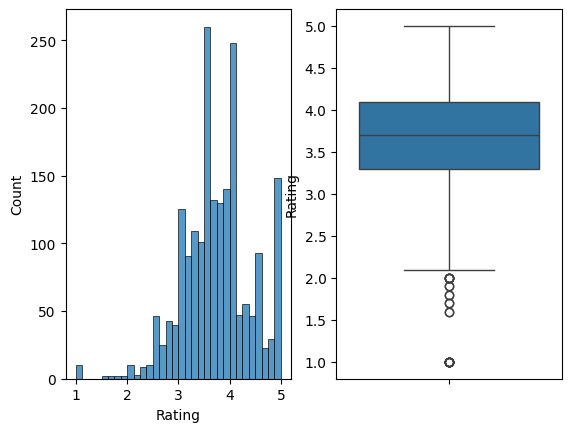

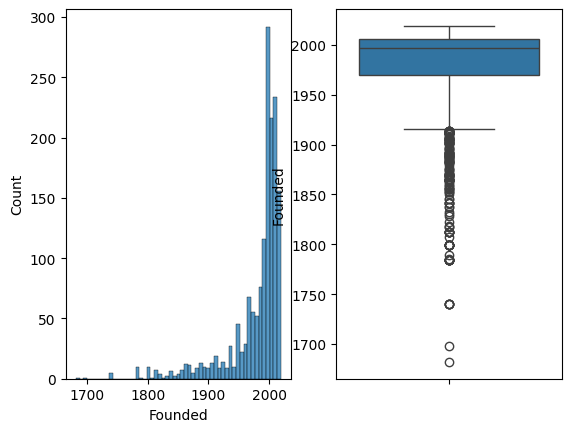

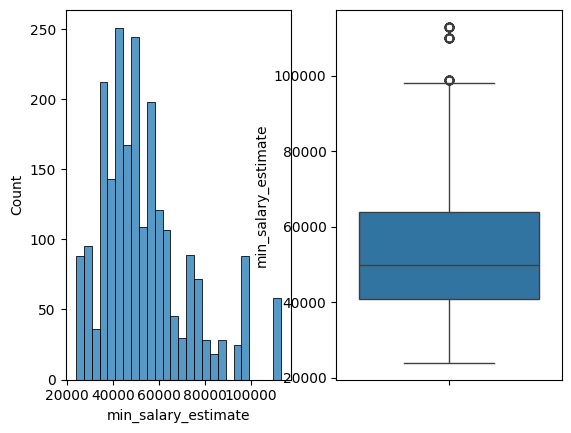

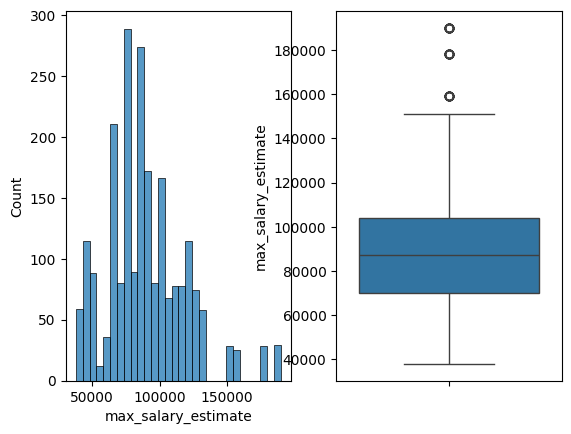

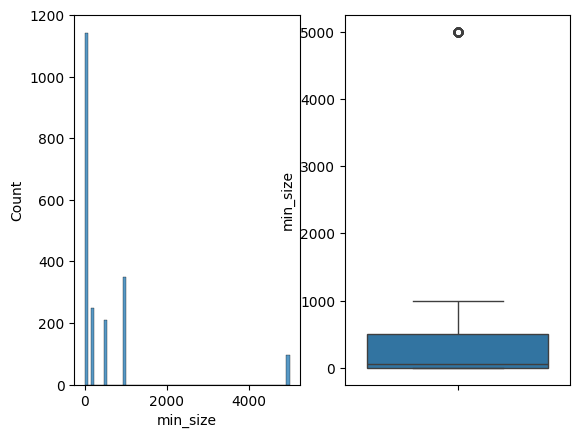

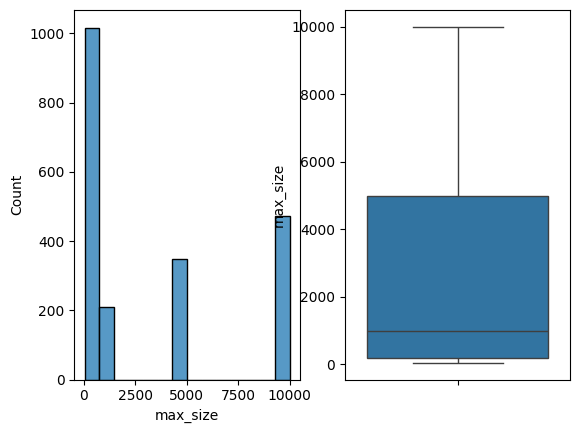

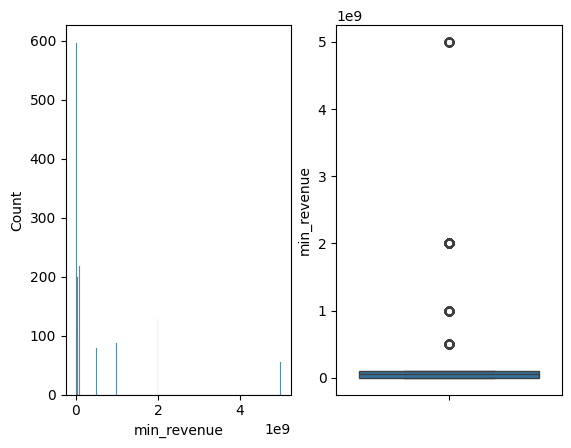

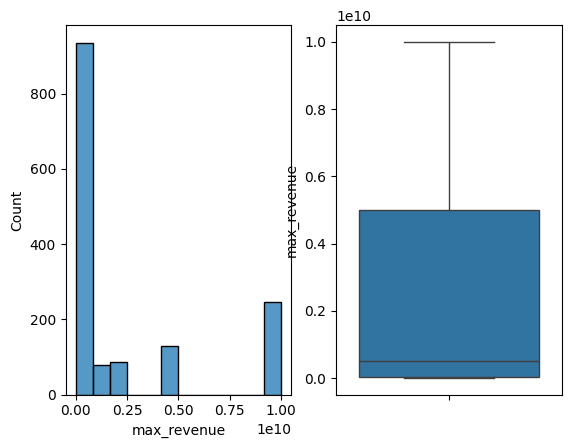

In [19]:
# uni-variate analysis
num_columns = df.select_dtypes(include="number").columns
for col in num_columns:
    fig, axes = plt.subplots(1, 2)
    sns.histplot(df[col], ax=axes[0])
    sns.boxplot(y=df[col], ax=axes[1])
    plt.show()

Job Title


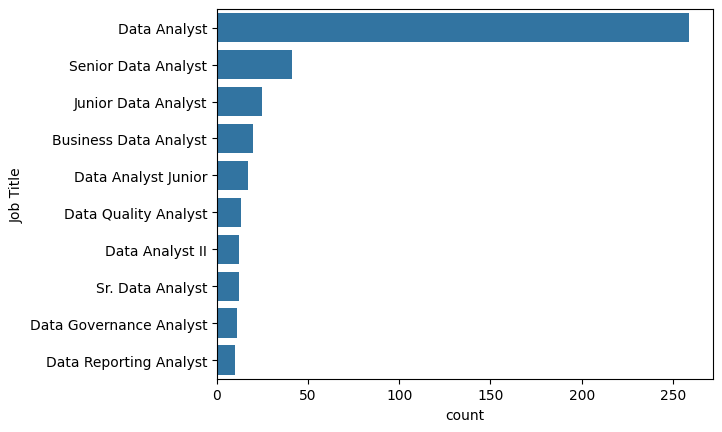

Company Name


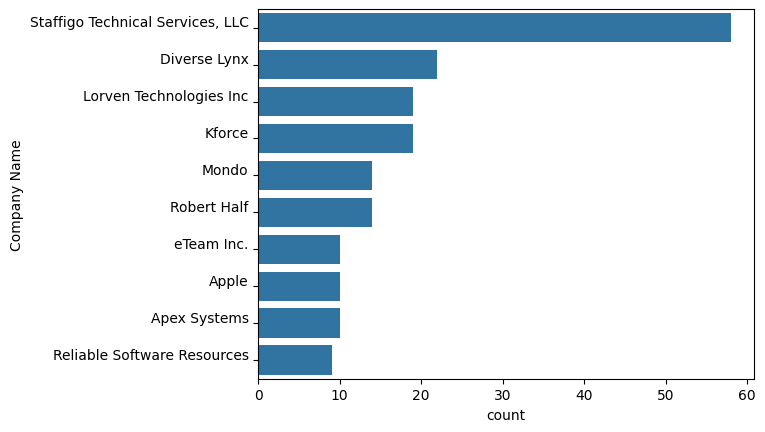

Location


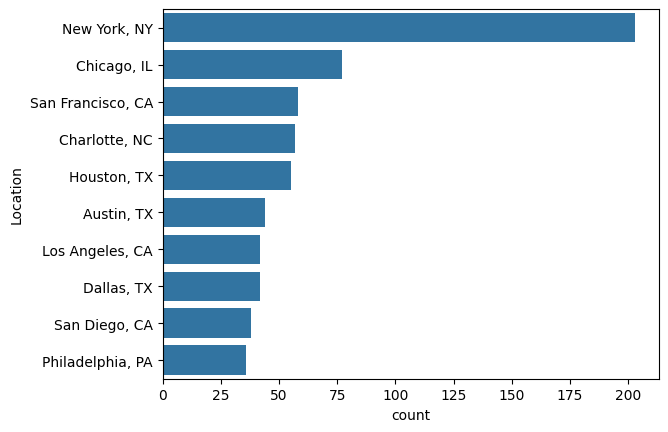

Headquarters


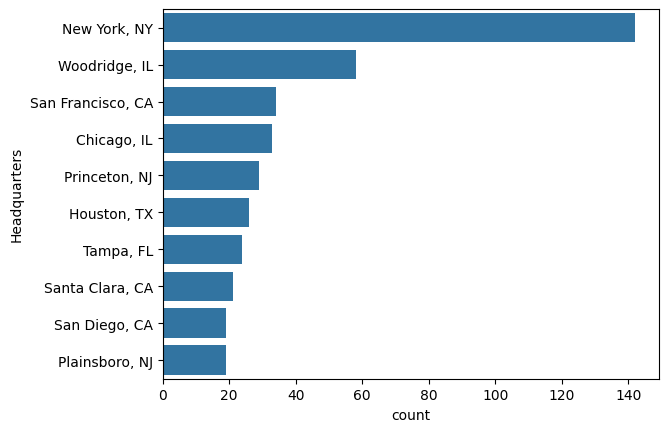

Type of ownership


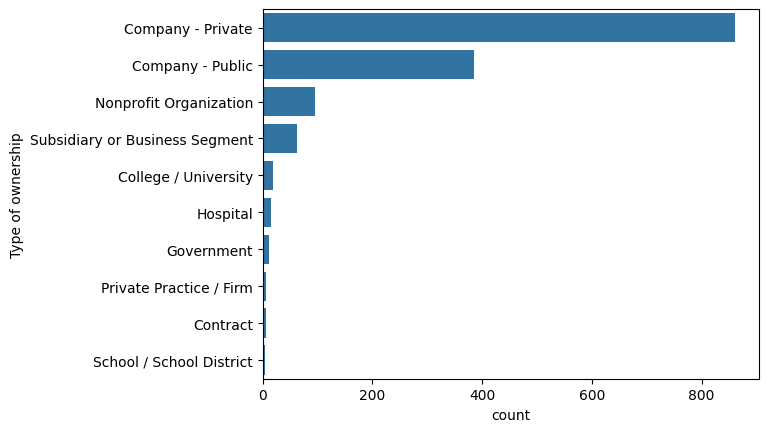

Industry


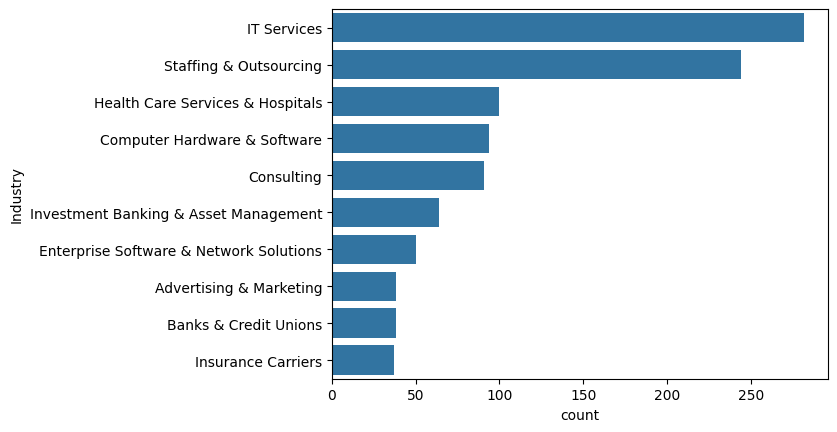

Sector


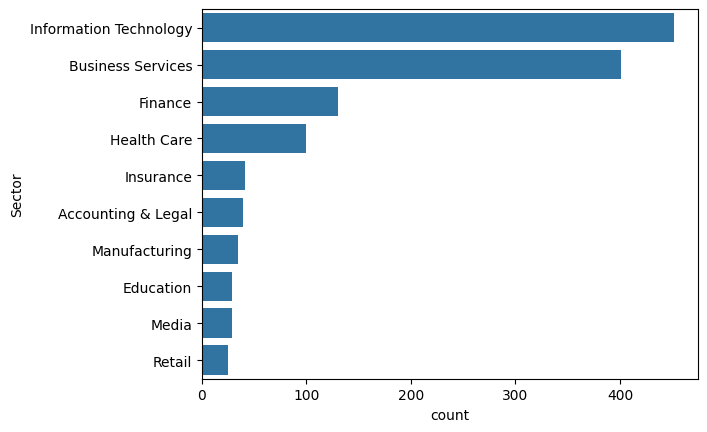

Competitors


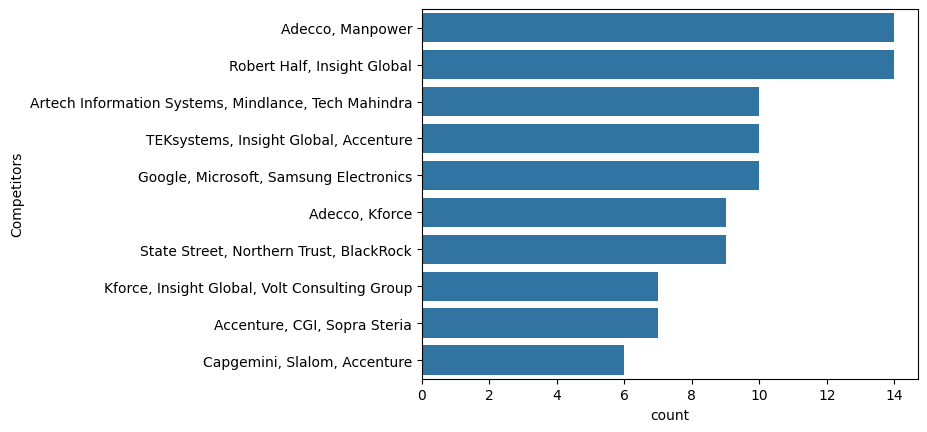

Easy Apply


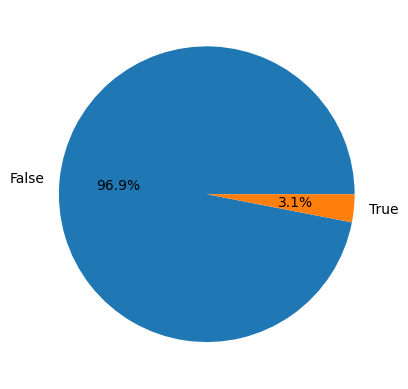

In [20]:
cat_columns = df.select_dtypes(include="O").columns
for col in cat_columns:
    print(col)
    if df[col].nunique() < 7:
        dff = df.groupby(col)[["max_revenue"]].count().rename(columns={'max_revenue':'count'})
        plt.pie(labels=dff.index, x=dff['count'], autopct="%1.1f%%")
    elif df[col].nunique() < 10:
        sns.countplot(y=df[col])
    else:
        dff = df.groupby(col)[["max_revenue"]].count().reset_index().sort_values(by='max_revenue', ascending=False).head(10).rename(columns={'max_revenue':'count'})
        sns.barplot(y=dff[col], x=dff['count'])
    plt.show()

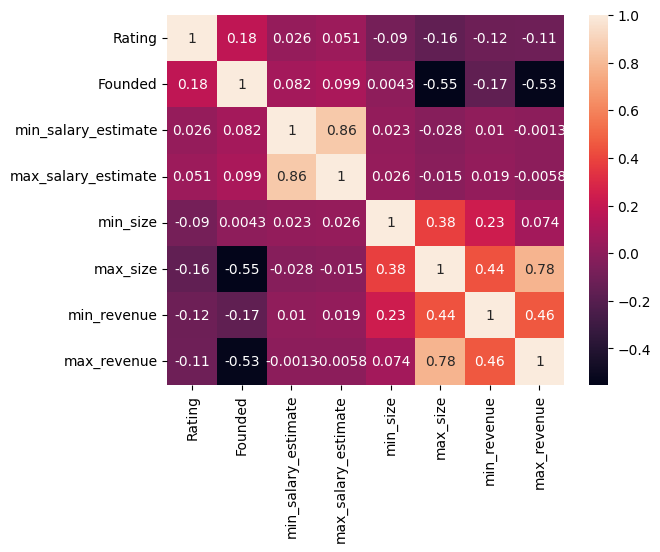

In [21]:
### bi-variate
sns.heatmap(df.select_dtypes("number").corr(), annot=True)
plt.show()

<Axes: xlabel='max_salary_estimate', ylabel='Company Name'>

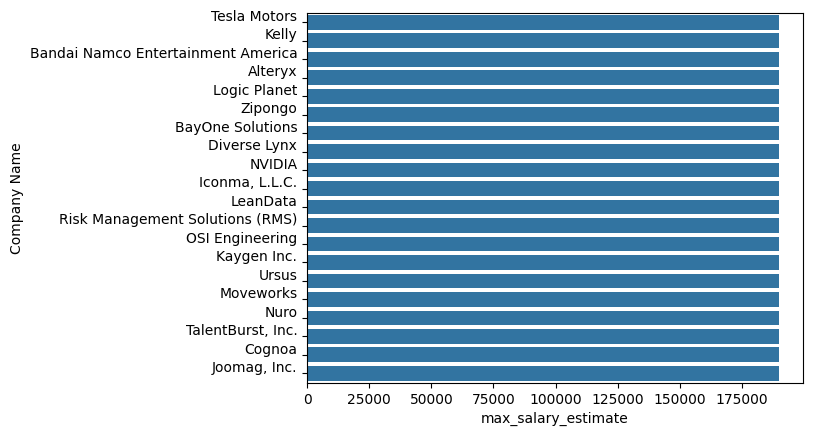

In [22]:
# what is the top 10 max_revenue companies
dff = df.sort_values(by='max_salary_estimate', ascending=False).head(20)
# Company Name: Cat
# Salary: Num
sns.barplot(y=dff['Company Name'], x=dff['max_salary_estimate'])

<Axes: xlabel='min_salary_estimate', ylabel='max_salary_estimate'>

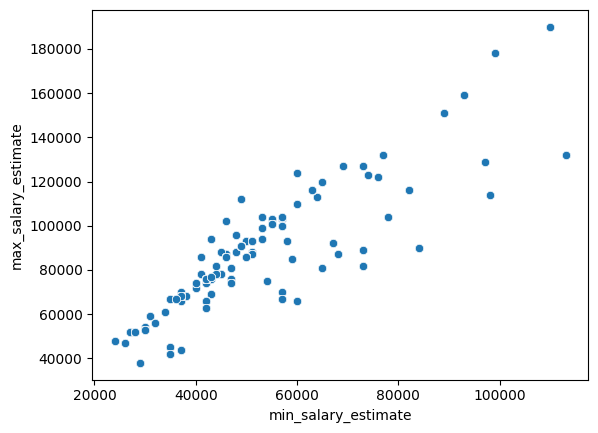

In [23]:
# relation btn max_size & max_revenue
sns.scatterplot(x=df['min_salary_estimate'], y=df['max_salary_estimate'])

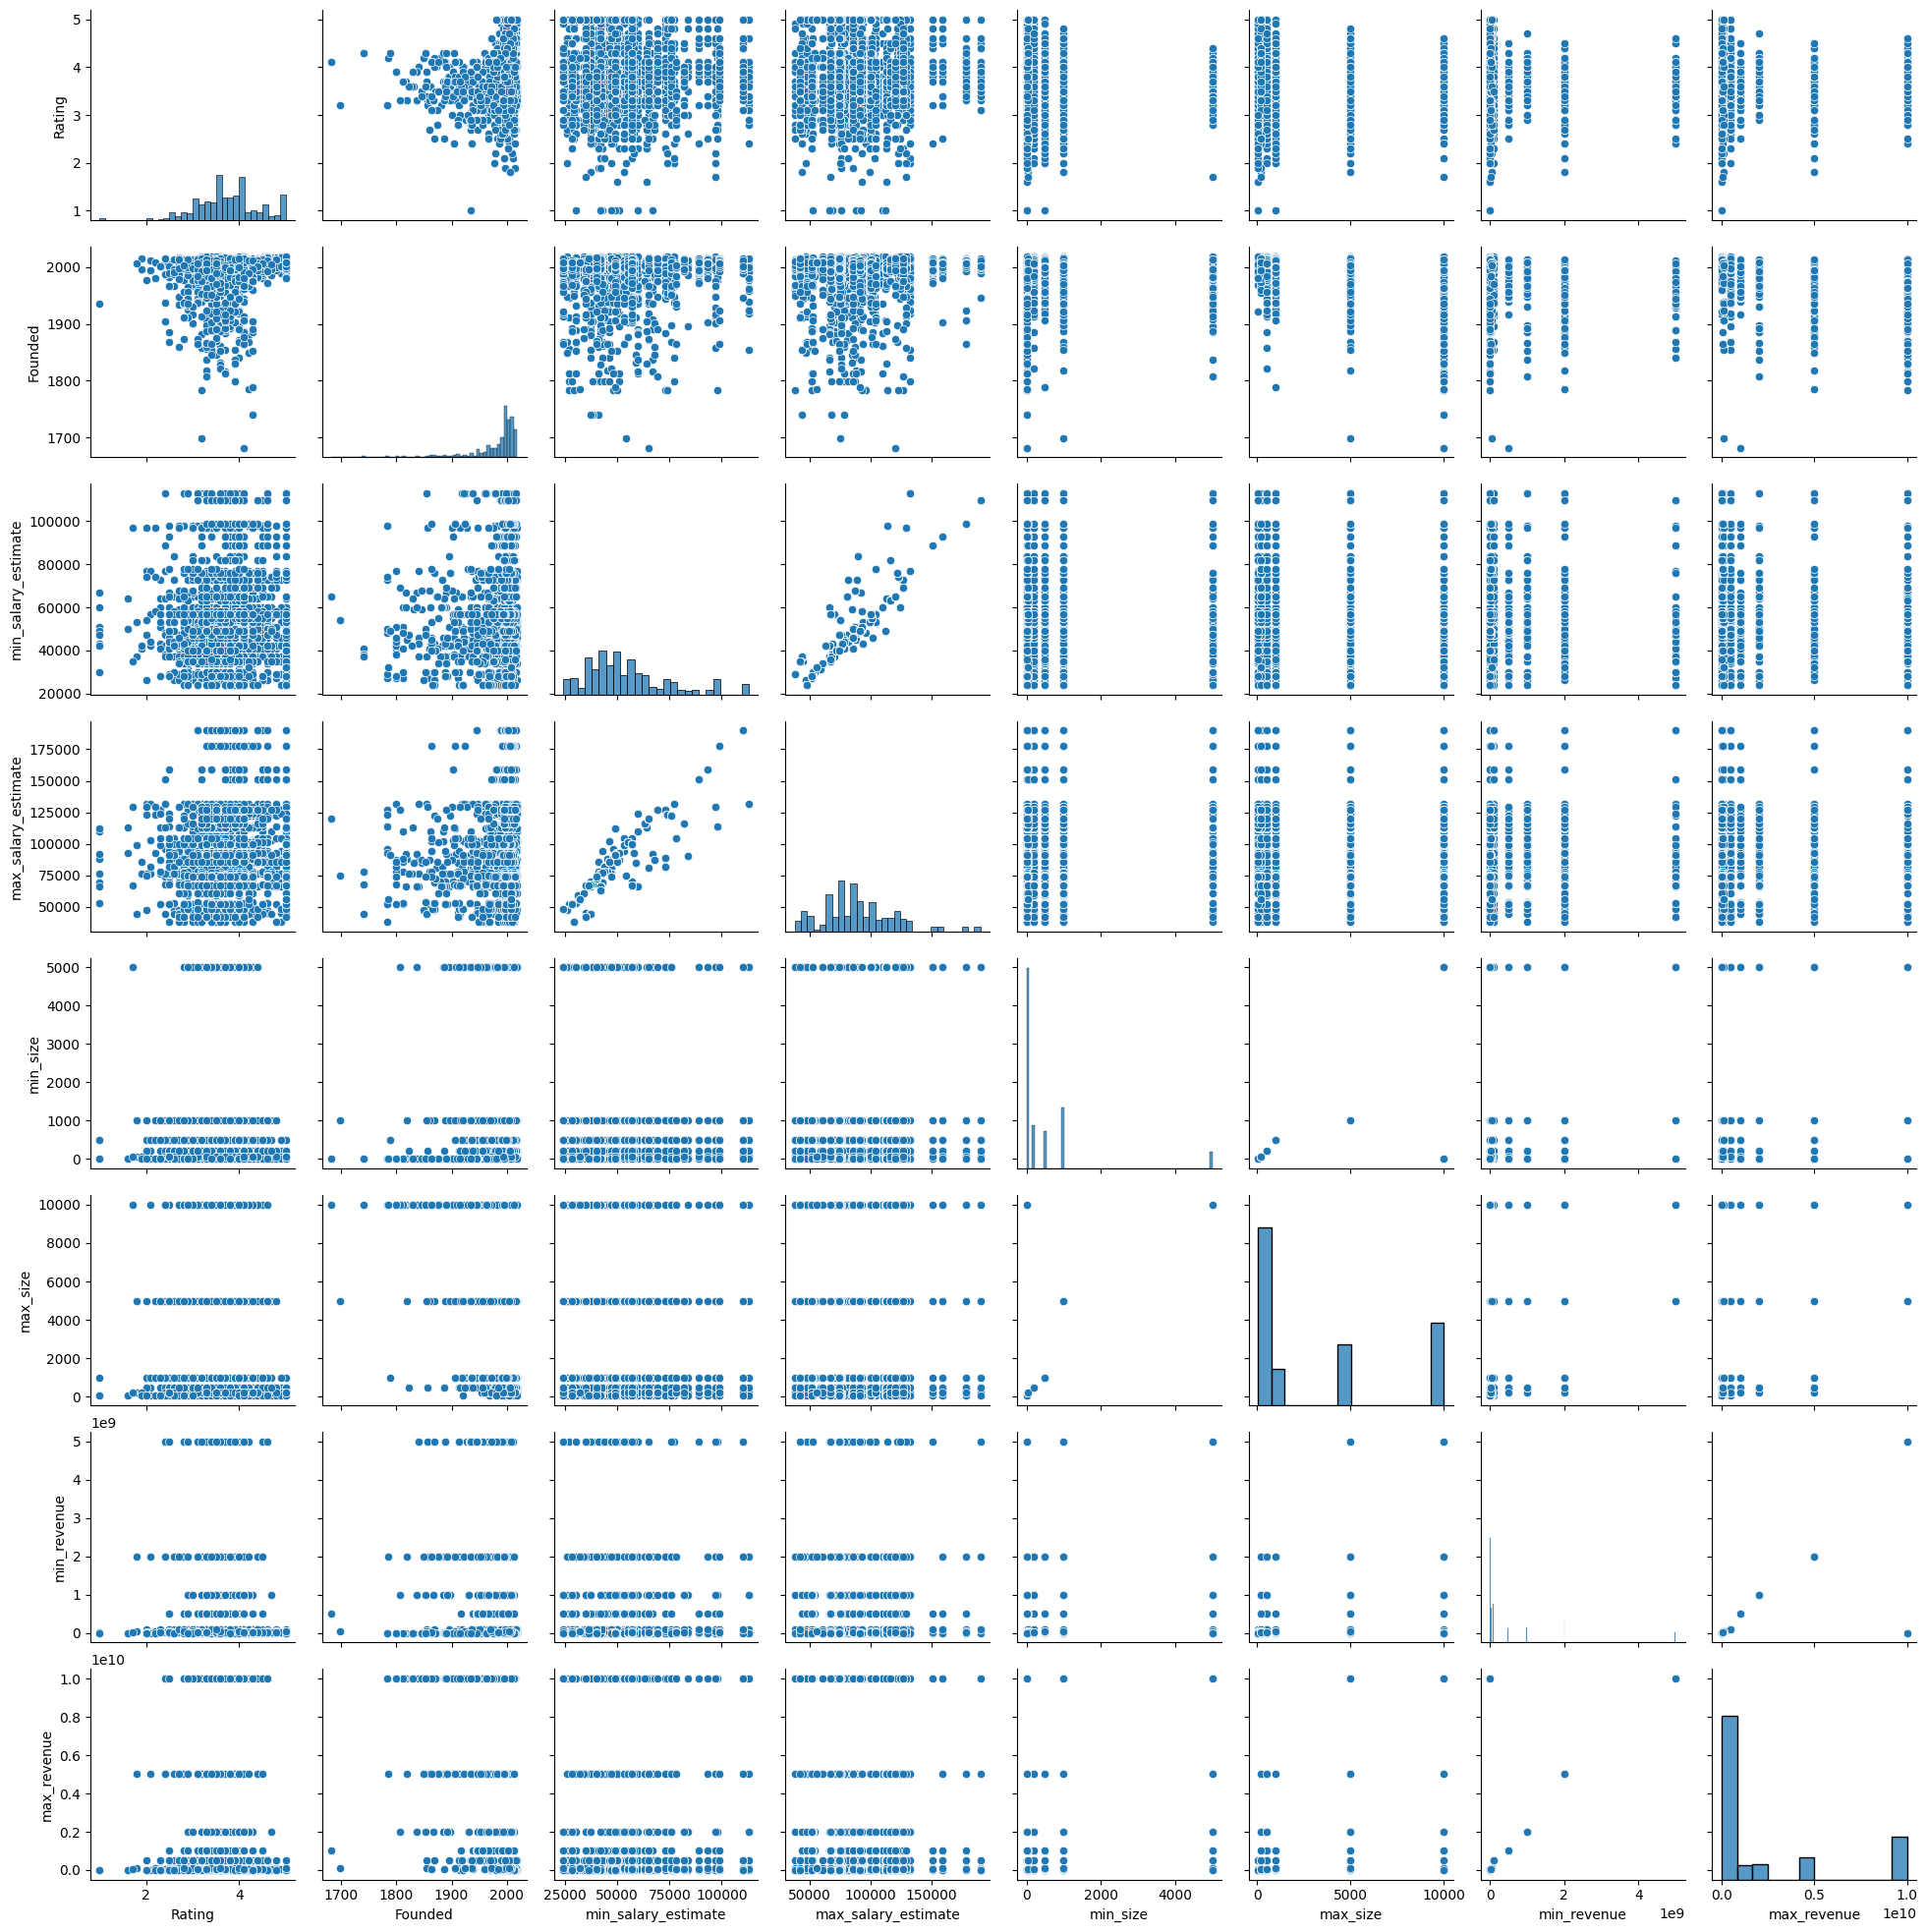

In [24]:
# multivaratie
sns.pairplot(df.select_dtypes('number'))

In [27]:
df[['min_size', 'max_size']] = df[['min_size', 'max_size']].astype(float)
df[['Easy Apply']] = df[['Easy Apply']].astype(bool).astype(int)
df

,Job Title,Rating,Company Name,Location,Headquarters,Founded,Type of ownership,Industry,Sector,Competitors,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
0,"Data Analyst, Center on Immigration and Justic...",3.2,Vera Institute of Justice\n,"New York, NY","New York, NY",1961.0,Nonprofit Organization,Social Assistance,Non-Profit,NaN,1,37000.0,66000.0,201.0,500.0,1.000000e+08,5.000000e+08
1,Quality Data Analyst,3.8,Visiting Nurse Service of New York\n,"New York, NY","New York, NY",1893.0,Nonprofit Organization,Health Care Services & Hospitals,Health Care,NaN,0,37000.0,66000.0,0.0,10000.0,2.000000e+09,5.000000e+09
2,"Senior Data Analyst, Insights & Analytics Team...",3.4,Squarespace\n,"New York, NY","New York, NY",2003.0,Company - Private,Internet,Information Technology,GoDaddy,0,37000.0,66000.0,1001.0,5000.0,NaN,NaN
3,Data Analyst,4.1,Celerity\n,"New York, NY","McLean, VA",2002.0,Subsidiary or Business Segment,IT Services,Information Technology,NaN,0,37000.0,66000.0,201.0,500.0,5.000000e+07,1.000000e+08
4,Reporting Data Analyst,3.9,FanDuel\n,"New York, NY","New York, NY",2009.0,Company - Private,Sports & Recreation,"Arts, Entertainment & Recreation",DraftKings,1,37000.0,66000.0,501.0,1000.0,1.000000e+08,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2248,RQS - IHHA - 201900004460 -1q Data Security An...,2.5,"Avacend, Inc.\n","Denver, CO","Alpharetta, GA",NaN,Company - Private,Staffing & Outsourcing,Business Services,NaN,0,78000.0,104000.0,51.0,200.0,NaN,NaN
2249,Senior Data Analyst (Corporate Audit),2.9,Arrow Electronics\n,"Centennial, CO","Centennial, CO",1935.0,Company - Public,Wholesale,Business Services,"Avnet, Ingram Micro, Tech Data",0,78000.0,104000.0,0.0,10000.0,0.000000e+00,1.000000e+10
2250,"Technical Business Analyst (SQL, Data analytic...",NaN,Spiceorb,"Denver, CO",NaN,NaN,NaN,NaN,NaN,NaN,0,78000.0,104000.0,NaN,NaN,NaN,NaN
2251,"Data Analyst 3, Customer Experience",3.1,Contingent Network Services\n,"Centennial, CO","West Chester, OH",1984.0,Company - Private,Enterprise Software & Network Solutions,Information Technology,NaN,0,78000.0,104000.0,201.0,500.0,2.500000e+07,5.000000e+07


### 3) Pre-Processing Mind Map:
* a) Detect & Handle Duplicates
* b) train_test_split
* c) Detect & Handle NaNs
* d) Detect & Handle Outliers
* e) Encoding: (Ordinal:[OrdinalEncoder, LabelEncoder] - Nominal: [< 7 uniques(OneHotEncoding), > 7 uniques (BinaryEncoder)])
* f) Imbalanced: X_train_resampled
* g) Scaling: StandardScaler, MinMaxScaler, RobustScaler: X_train_resampled_scaled

In [28]:
# * a) Detect & Handle Duplicates
df.duplicated().sum()

np.int64(0)

In [29]:
df.drop_duplicates(inplace=True)

In [52]:
# * b) train_test_split
from sklearn.model_selection import train_test_split

X = df.drop(['Rating', 'Competitors'], axis=1)
y = df['Rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1802, 15), (451, 15), (1802,), (451,))

In [53]:
# * c) Detect & Handle NaNs
X_train.isna().sum()

Job Title                0
Company Name             1
Location                 0
Headquarters           137
Founded                534
Type of ownership      141
Industry               282
Sector                 282
Easy Apply               0
min_salary_estimate      1
max_salary_estimate      1
min_size               165
max_size               165
min_revenue            619
max_revenue            619
dtype: int64

In [54]:
X_train.columns

Index(['Job Title', 'Company Name', 'Location', 'Headquarters', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Easy Apply',
       'min_salary_estimate', 'max_salary_estimate', 'min_size', 'max_size',
       'min_revenue', 'max_revenue'],
      dtype='object')

In [55]:
# impute
from sklearn.impute import SimpleImputer, KNNImputer

median_imputer = SimpleImputer(strategy='median')
X_train[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']] = median_imputer.fit_transform(X_train[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']])
X_test[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']] = median_imputer.transform(X_test[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']])

In [56]:
cols = ['Job Title', 'Company Name', 'Location', 'Headquarters', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Easy Apply', 'min_size', 'max_size']

mode_imputer = SimpleImputer(strategy='most_frequent')
X_train[cols] = mode_imputer.fit_transform(X_train[cols])
X_test[cols] = mode_imputer.transform(X_test[cols])

X_train[['min_size', 'max_size']] = X_train[['min_size', 'max_size']].astype(float)
X_train[['Easy Apply']] = X_train[['Easy Apply']].astype(bool).astype(int)

X_test[['min_size', 'max_size']] = X_test[['min_size', 'max_size']].astype(float)
X_test[['Easy Apply']] = X_test[['Easy Apply']].astype(bool).astype(int)


In [57]:
X_train.isna().sum()

Job Title              0
Company Name           0
Location               0
Headquarters           0
Founded                0
Type of ownership      0
Industry               0
Sector                 0
Easy Apply             0
min_salary_estimate    0
max_salary_estimate    0
min_size               0
max_size               0
min_revenue            0
max_revenue            0
dtype: int64

In [58]:
# * d) Detect & Handle Outliers
X_train

,Job Title,Company Name,Location,Headquarters,Founded,Type of ownership,Industry,Sector,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue
121,Data Analyst,New York Life Insurance Co\n,"New York, NY","New York, NY",1845.0,Company - Private,Insurance Agencies & Brokerages,Insurance,0,59000.0,85000.0,0.0,10000.0,0.0,1.000000e+10
173,Sr. Data Profiling Analyst,UBS\n,"New York, NY","Zurich, Switzerland",1862.0,Company - Public,Investment Banking & Asset Management,Finance,0,43000.0,76000.0,0.0,10000.0,0.0,1.000000e+10
1245,Data Analyst with Security Clearance,CDO Technologies Inc\n,"San Antonio, TX","Dayton, OH",1995.0,Company - Private,Computer Hardware & Software,Information Technology,0,73000.0,89000.0,201.0,500.0,50000000.0,1.000000e+08
1323,"Analyst, Data Intelligence",The Richards Group\n,"Dallas, TX","Dallas, TX",1957.0,Company - Private,Advertising & Marketing,Business Services,0,24000.0,48000.0,501.0,1000.0,100000000.0,5.000000e+08
999,Data Analyst,Net Orbit Inc\n,"Tempe, AZ","Tempe, AZ",2008.0,Company - Private,Staffing & Outsourcing,Information Technology,0,46000.0,102000.0,501.0,1000.0,50000000.0,5.000000e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,Data Quality Analyst,MedSeek\n,"Austin, TX","Hoover, AL",1996.0,Company - Private,Computer Hardware & Software,Information Technology,0,42000.0,76000.0,51.0,200.0,25000000.0,5.000000e+07
1095,Data Analyst,PMHCC Inc.\n,"Philadelphia, PA","Philadelphia, PA",1987.0,Nonprofit Organization,Health Care Services & Hospitals,Health Care,0,38000.0,68000.0,501.0,1000.0,50000000.0,5.000000e+08
1130,SQL Data Analyst,"Zachary Piper Solutions, LLC\n","Horsham, PA","Mc Lean, VA",2011.0,Company - Private,Enterprise Software & Network Solutions,Information Technology,0,37000.0,44000.0,51.0,200.0,10000000.0,2.500000e+07
1294,Data Analyst Junior,"Staffigo Technical Services, LLC\n","San Diego, CA","Woodridge, IL",2008.0,Company - Private,IT Services,Information Technology,0,60000.0,124000.0,51.0,200.0,50000000.0,1.000000e+08


<Axes: ylabel='min_salary_estimate'>

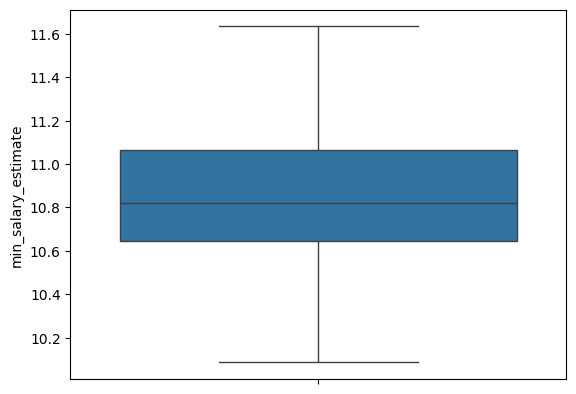

In [59]:
X_train[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']] = np.log1p(X_train[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']])
X_test[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']] = np.log1p(X_test[['min_salary_estimate', 'max_salary_estimate', 'min_revenue', 'max_revenue']])

sns.boxplot(X_train['min_salary_estimate'])

<Axes: xlabel='min_salary_estimate', ylabel='Count'>

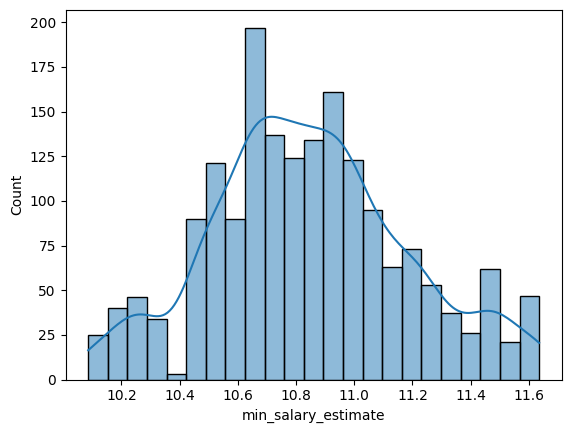

In [60]:
sns.histplot(X_train['min_salary_estimate'], kde=True)

In [61]:
# * e) Encoding: (Ordinal:[OrdinalEncoder, LabelEncoder] - Nominal: [< 7 uniques(OneHotEncoding), > 7 uniques (BinaryEncoder)])
cat_cols = X_train.select_dtypes("O").columns
for col in cat_cols:
    print(col, X_train[col].nunique())

Job Title 1046
Company Name 1259
Location 227
Headquarters 428
Founded 154
Type of ownership 13
Industry 82
Sector 23


In [64]:
bin_encoder = BinaryEncoder()
train_cat_encoded = bin_encoder.fit_transform(X_train[cat_cols])
X_train_encoded = pd.concat([X_train, train_cat_encoded], axis=1)
X_train_encoded.drop(cat_cols, axis=1, inplace=True)

test_cat_encoded = bin_encoder.transform(X_test[cat_cols])
X_test_encoded = pd.concat([X_test, test_cat_encoded], axis=1)
X_test_encoded.drop(cat_cols, axis=1, inplace=True)

In [66]:
std_scaling_cols = ["min_salary_estimate", "max_salary_estimate", "min_revenue", "max_revenue"]
std_scaler = StandardScaler()
X_train_encoded[std_scaling_cols] = std_scaler.fit_transform(X_train_encoded[std_scaling_cols])
X_test_encoded[std_scaling_cols] = std_scaler.transform(X_test_encoded[std_scaling_cols])

robust_scaling_cols = ["min_size", "max_size"]
robust_scaler = RobustScaler()
X_train_encoded[robust_scaling_cols] = robust_scaler.fit_transform(X_train_encoded[robust_scaling_cols])
X_test_encoded[robust_scaling_cols] = robust_scaler.transform(X_test_encoded[robust_scaling_cols])

In [67]:
X_train_encoded

,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue,Job Title_0,Job Title_1,Job Title_2,...,Industry_2,Industry_3,Industry_4,Industry_5,Industry_6,Sector_0,Sector_1,Sector_2,Sector_3,Sector_4
121,0,0.412564,-0.019356,-0.102,0.918367,-2.537409,1.533203,0,0,0,...,0,0,0,0,1,0,0,0,0,1
173,0,-0.518706,-0.365960,-0.102,0.918367,-2.537409,1.533203,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1245,0,1.039391,0.123058,0.300,-0.051020,0.331249,-0.465121,0,0,0,...,0,0,0,1,1,0,0,0,1,1
1323,0,-2.235419,-1.789101,0.900,0.000000,0.443414,0.233263,0,0,0,...,0,0,1,0,0,0,0,1,0,0
999,0,-0.320165,0.545285,0.900,0.000000,0.331249,0.233263,0,0,0,...,0,0,1,0,1,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1638,0,-0.587978,-0.365960,0.000,-0.081633,0.219084,-0.765898,0,0,0,...,0,0,0,1,1,0,0,0,1,1
1095,0,-0.882613,-0.710419,0.900,0.000000,0.331249,0.233263,0,0,0,...,0,1,1,1,1,0,1,0,1,1
1130,0,-0.961122,-2.058568,0.000,-0.081633,0.070811,-1.066676,0,0,0,...,0,0,1,1,1,0,0,0,1,1
1294,0,0.462043,1.150148,0.000,-0.081633,0.331249,-0.465121,0,0,0,...,0,1,0,0,1,0,0,0,1,1


In [68]:
X_train_encoded.describe()

,Easy Apply,min_salary_estimate,max_salary_estimate,min_size,max_size,min_revenue,max_revenue,Job Title_0,Job Title_1,Job Title_2,...,Industry_2,Industry_3,Industry_4,Industry_5,Industry_6,Sector_0,Sector_1,Sector_2,Sector_3,Sector_4
count,1802.000000,1.802000e+03,1.802000e+03,1802.000000,1802.000000,1.802000e+03,1.802000e+03,1802.000000,1802.000000,1802.000000,...,1802.000000,1802.000000,1802.000000,1802.000000,1802.000000,1802.00000,1802.000000,1802.000000,1802.000000,1802.000000
mean,0.034961,4.437935e-15,8.241034e-16,0.779799,0.302283,3.055886e-16,1.841418e-15,0.012764,0.304661,0.321865,...,0.217536,0.342397,0.540511,0.376249,0.790233,0.04939,0.150943,0.339623,0.648169,0.594340
std,0.183732,1.000278e+00,1.000278e+00,2.003688,0.435872,1.000278e+00,1.000278e+00,0.112284,0.460392,0.467321,...,0.412685,0.474643,0.498495,0.484578,0.407255,0.21674,0.358093,0.473713,0.477674,0.491156
min,0.000000,-2.235419e+00,-2.512586e+00,-0.102000,-0.096939,-2.537409e+00,-2.463443e+00,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,-5.879776e-01,-6.206465e-01,-0.100000,-0.081633,7.081084e-02,-4.651206e-01,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,-7.469725e-02,5.266946e-02,0.000000,0.000000,3.312490e-01,2.332634e-01,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,1.000000,0.00000,0.000000,0.000000,1.000000,1.000000
75%,0.000000,6.520392e-01,6.054223e-01,0.900000,0.918367,3.312490e-01,2.332634e-01,0.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,0.00000,0.000000,1.000000,1.000000,1.000000
max,1.000000,2.325682e+00,2.471755e+00,9.900000,0.918367,1.076455e+00,1.533203e+00,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [69]:
X_train_encoded.to_csv("train_cleaned_encoded.csv", index=False)
X_test_encoded.to_csv("test_cleaned_encoded.csv", index=False)